# 260918 GITT OCP QC and Stage 1 Preparation

This notebook performs parser and QC preparation only. It keeps v2 and v3 independent until normalized comparisons are calculated.

Guardrails:

- `Q_NORM_NEW` is a normalized position, not absolute stoichiometry.
- The new candidate is not injected into Stage 1.
- No parameter sensitivity or Stage 2–4 fitting is run.
- The raw Neware workbooks are read-only inputs.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

from gitt_ocp_qc import ANODE_OCP_CASE, run_qc, select_anode_ocp_source

ROOT = Path.cwd().resolve()
QC = run_qc(ROOT)
RESULTS = QC["paths"].results
print("Results:", RESULTS)

Results: C:\Users\user\Documents\Codex\2026-09-18\https-github-com-rinny-hi-ai2020\work\ai2020_dfn_fitting\results\260918_gitt_ocp_qc


## Section A — Raw data parser

In [2]:
display(QC['parser_status'])

,cell,source_file,sheet_names,step_count,gitt_step_count,pulse_count,two_hour_rest_count,record_mapping_complete,status
0,v2,260918 Anode GITT v2 1-6.xlsx,"unit, test, cycle, step, record, log, idle, curve",186,181,90,91,True,OK
1,v3,260918 Anode GITT v3 1-7.xlsx,"unit, test, cycle, step, record, log, idle, curve",192,187,93,94,True,OK


The parser locates GITT steps from step type, cycle, duration, and sequence. Record rows are assigned by timestamp boundaries rather than hard-coded row numbers.

## Section B — GITT pulse / rest identification

In [3]:
display(QC["pulse_rest"].head(12))
display(QC["pulse_rest"].groupby(["cell", "direction"]).size().rename("pulse_count").reset_index())

,cell,direction,pulse_number,pulse_step_number,pulse_start_time,pulse_end_time,pulse_duration_min,pulse_current_mA_signed,pulse_current_mA_abs,pulse_capacity_increment_mAh,...,rest_duration_min,rest_start_voltage_V,rest_voltage_at_60_min_V,rest_end_voltage_at_120_min_V,delta_V_2h_minus_1h_mV,last_10_min_slope_mV_per_min,last_10_min_abs_dVdt_mV_per_min,rest_record_count,branch_usable_capacity_mAh,q_norm_branch
0,v2,lithiation,1,7,2026-09-07 06:45:47,2026-09-07 06:55:47,10.0,-0.229,0.229,0.04,...,120.000000,0.4359,0.4805,0.4812,0.7,6.100795e-03,6.100795e-03,7201,1.79,0.022346
1,v2,lithiation,2,9,2026-09-07 08:55:47,2026-09-07 09:05:47,10.0,-0.229,0.229,0.04,...,120.000000,0.3127,0.3551,0.3557,0.6,6.117711e-03,6.117711e-03,7201,1.79,0.044693
2,v2,lithiation,3,11,2026-09-07 11:05:47,2026-09-07 11:15:47,10.0,-0.229,0.229,0.04,...,120.000000,0.2344,0.2759,0.2763,0.4,9.419517e-05,9.419517e-05,7201,1.79,0.067039
3,v2,lithiation,4,13,2026-09-07 13:15:47,2026-09-07 13:25:47,10.0,-0.229,0.229,0.04,...,120.000000,0.1834,0.2220,0.2224,0.4,8.419191e-03,8.419191e-03,7201,1.79,0.089385
4,v2,lithiation,5,15,2026-09-07 15:25:47,2026-09-07 15:35:47,10.0,-0.229,0.229,0.04,...,120.000000,0.1710,0.2100,0.2104,0.4,-8.232922e-16,8.232922e-16,7201,1.79,0.111732
5,v2,lithiation,6,17,2026-09-07 17:35:47,2026-09-07 17:45:47,10.0,-0.229,0.229,0.04,...,119.983333,0.1667,0.2081,0.2087,0.6,9.485851e-05,9.485851e-05,7201,1.79,0.134078
6,v2,lithiation,7,19,2026-09-07 19:45:46,2026-09-07 19:55:46,10.0,-0.229,0.229,0.04,...,120.000000,0.1619,0.2057,0.2065,0.8,1.283077e-02,1.283077e-02,7201,1.79,0.156425
7,v2,lithiation,8,21,2026-09-07 21:55:46,2026-09-07 22:05:46,10.0,-0.229,0.229,0.04,...,120.000000,0.1560,0.2016,0.2026,1.0,1.299926e-02,1.299926e-02,7201,1.79,0.178771
8,v2,lithiation,9,23,2026-09-08 00:05:46,2026-09-08 00:15:46,10.0,-0.229,0.229,0.04,...,120.000000,0.1490,0.1945,0.1955,1.0,8.891493e-03,8.891493e-03,7201,1.79,0.201117
9,v2,lithiation,10,25,2026-09-08 02:15:46,2026-09-08 02:25:46,10.0,-0.229,0.229,0.04,...,120.000000,0.1405,0.1845,0.1852,0.7,1.840786e-03,1.840786e-03,7201,1.79,0.223464


,cell,direction,pulse_count
0,v2,delithiation,45
1,v2,lithiation,45
2,v3,delithiation,46
3,v3,lithiation,47


## Section C — 1 h vs 2 h relaxation comparison

,cell,direction,region,n,mean,median,mean_abs,median_abs,p90_abs,max_abs
0,v2,delithiation,full,45,-1.648889,-0.60,1.648889,0.60,1.76,27.4
1,v2,delithiation,central_10_90,35,-0.771429,-0.60,0.771429,0.60,1.60,1.9
2,v2,delithiation,endpoints,10,-4.720000,-0.50,4.720000,0.50,16.15,27.4
3,v2,lithiation,full,45,0.933333,0.70,0.933333,0.70,1.64,4.5
4,v2,lithiation,central_10_90,36,0.980556,0.70,0.980556,0.70,1.60,4.5
5,v2,lithiation,endpoints,9,0.744444,0.50,0.744444,0.50,1.12,2.8
6,v3,delithiation,full,46,-1.171739,-0.50,1.171739,0.50,1.50,24.5
7,v3,delithiation,central_10_90,37,-0.672973,-0.50,0.672973,0.50,1.40,1.8
8,v3,delithiation,endpoints,9,-3.222222,-0.50,3.222222,0.50,6.18,24.5
9,v3,lithiation,full,47,0.931915,0.70,0.931915,0.70,1.42,4.8


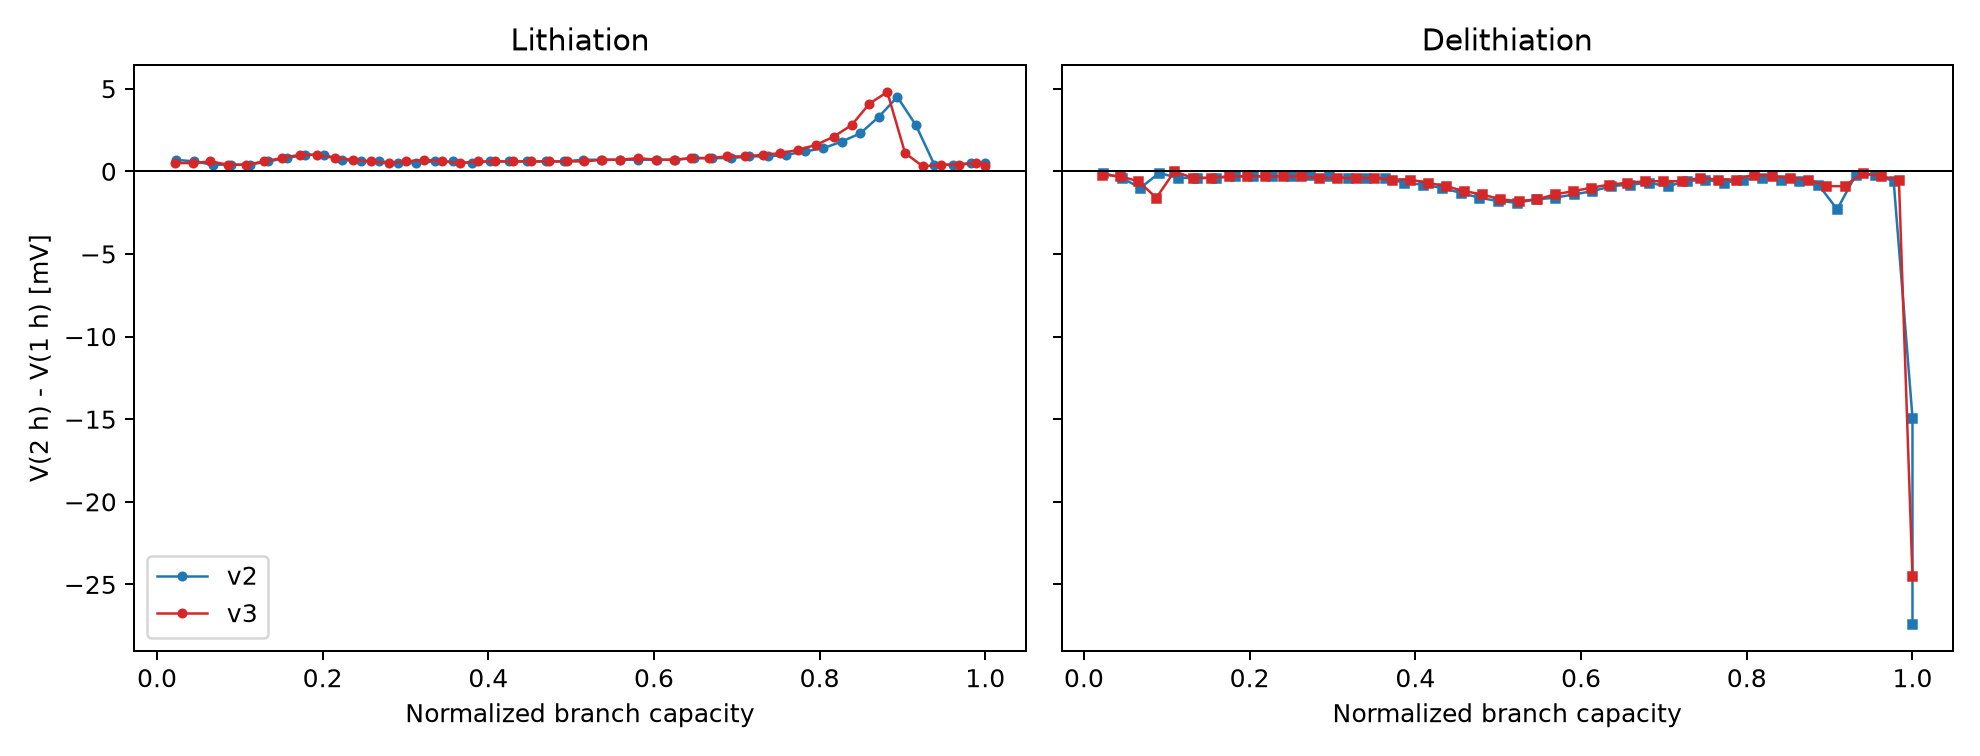

In [4]:
display(QC["relaxation_metrics"])
display(Image(filename=str(RESULTS / "anode_rest_1h_vs_2h.png")))

## Section D — Rest equilibrium quality

Method: linear-regression slope over the final 10 minutes of each 2 h rest.


,cell,direction,region,n,mean,median,mean_abs,median_abs,p90_abs,max_abs
0,v2,delithiation,full,45,-0.018666,-0.004065,0.018666,0.004065,0.023025,0.333041
1,v2,delithiation,central_10_90,35,-0.007734,-0.003229,0.007734,0.003229,0.018857,0.024333
2,v2,delithiation,endpoints,10,-0.056929,-0.011087,0.056929,0.011087,0.187335,0.333041
3,v2,lithiation,full,45,0.010572,0.009383,0.010572,0.009383,0.015591,0.054476
4,v2,lithiation,central_10_90,36,0.010850,0.010190,0.010850,0.010190,0.015466,0.054476
5,v2,lithiation,endpoints,9,0.009461,0.006118,0.009461,0.006118,0.018462,0.044245
6,v3,delithiation,full,46,-0.014048,-0.008633,0.014048,0.008633,0.017498,0.306018
7,v3,delithiation,central_10_90,37,-0.008121,-0.008831,0.008121,0.008831,0.015544,0.021868
8,v3,delithiation,endpoints,9,-0.038417,-0.000438,0.038417,0.000438,0.076242,0.306018
9,v3,lithiation,full,47,0.009863,0.009070,0.009863,0.009070,0.016668,0.060634


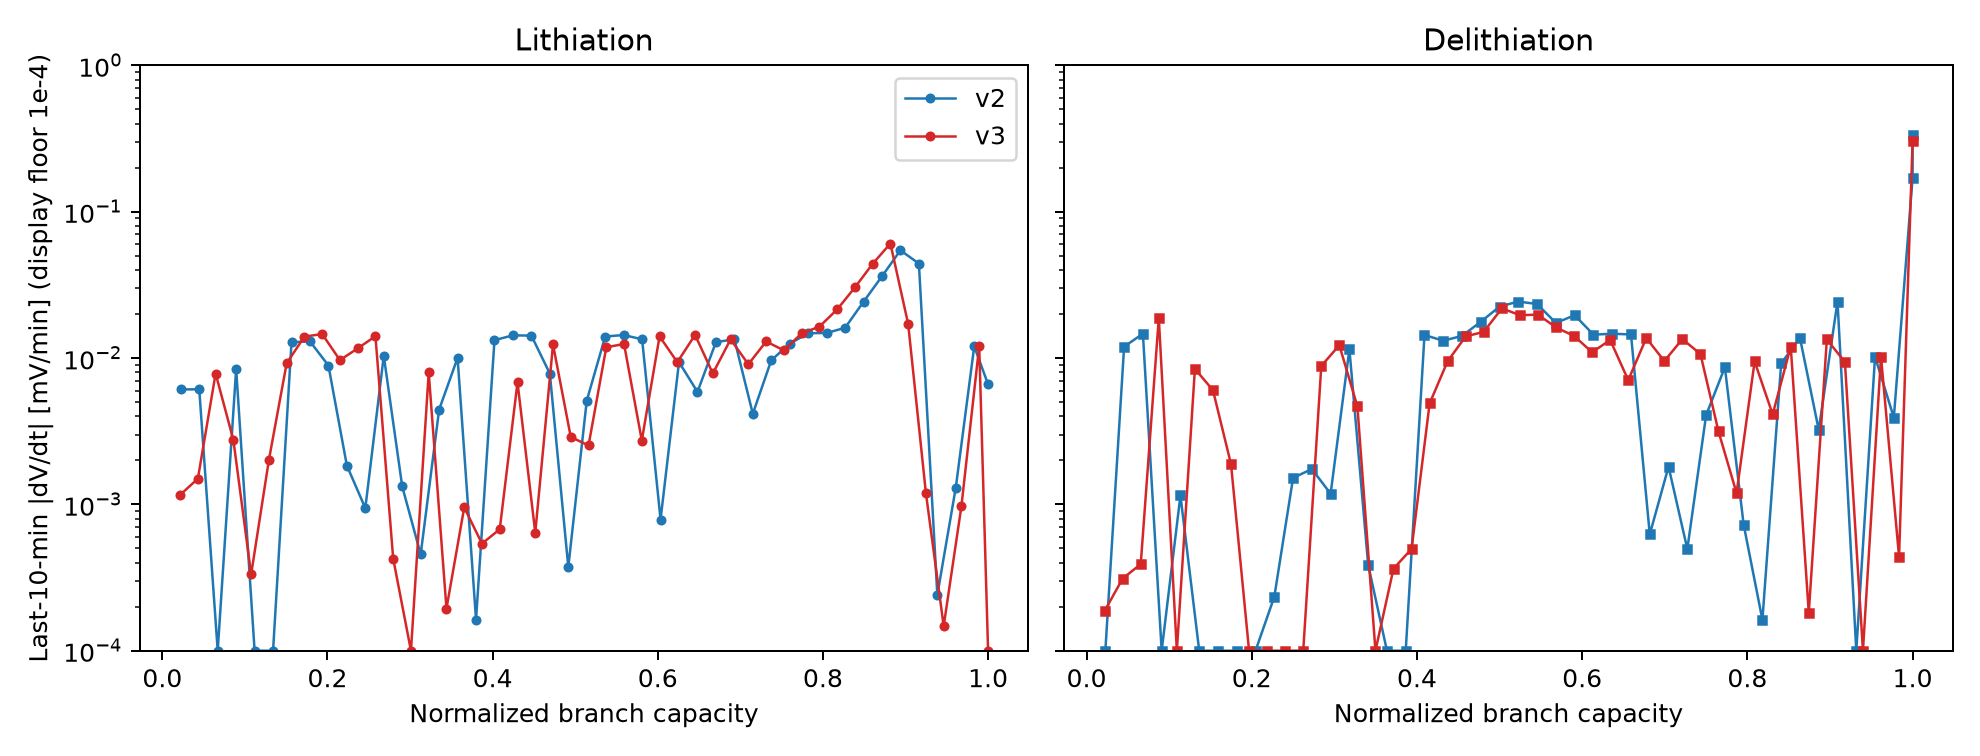

In [5]:
print("Method: linear-regression slope over the final 10 minutes of each 2 h rest.")
display(QC["equilibrium_metrics"])
display(Image(filename=str(RESULTS / "anode_rest_equilibrium.png")))

## Section E — Capacity QC

In [6]:
display(QC["capacity_qc"])
print("The 2.20–2.25 mAh reference is a full-cell operating-window sanity check only. No correction is applied.")

,cell,initial_lithiation_cycle1_mAh,initial_delithiation_cycle1_mAh,initial_lithiation_cycle2_mAh,initial_delithiation_cycle2_mAh,gitt_lithiation_capacity_mAh,gitt_delithiation_capacity_mAh,gitt_reversible_capacity_mean_mAh,gitt_lith_minus_delith_mAh,gitt_delith_over_lith_ratio,full_cell_window_reference_low_mAh,full_cell_window_reference_high_mAh,automatic_capacity_correction_applied,v2_v3_gitt_lithiation_capacity_mAh_difference_pct,v2_v3_gitt_delithiation_capacity_mAh_difference_pct
0,v2,2.10,1.98,1.78,1.77,1.79,1.76,1.775,0.03,0.983240,2.2,2.25,False,3.835616,3.899721
1,v3,2.03,1.94,1.76,1.75,1.86,1.83,1.845,0.03,0.983871,2.2,2.25,False,3.835616,3.899721


The 2.20–2.25 mAh reference is a full-cell operating-window sanity check only. No correction is applied.


## Section F — v2 / v3 normalized reproducibility

,comparison,direction,region,MAE_mV,RMSE_mV,median_absolute_difference_mV,P90_absolute_difference_mV,max_absolute_difference_mV
0,v2_minus_v3,lithiation,full_overlap,3.081916,5.609481,1.12280,9.807125,21.923175
1,v2_minus_v3,lithiation,central_10_90,1.648878,2.501224,0.76650,3.947775,10.487500
2,v2_minus_v3,delithiation,full_overlap,2.281235,6.494250,1.00615,4.907875,64.484800
3,v2_minus_v3,delithiation,central_10_90,1.029306,1.717956,0.76090,1.839700,11.367500


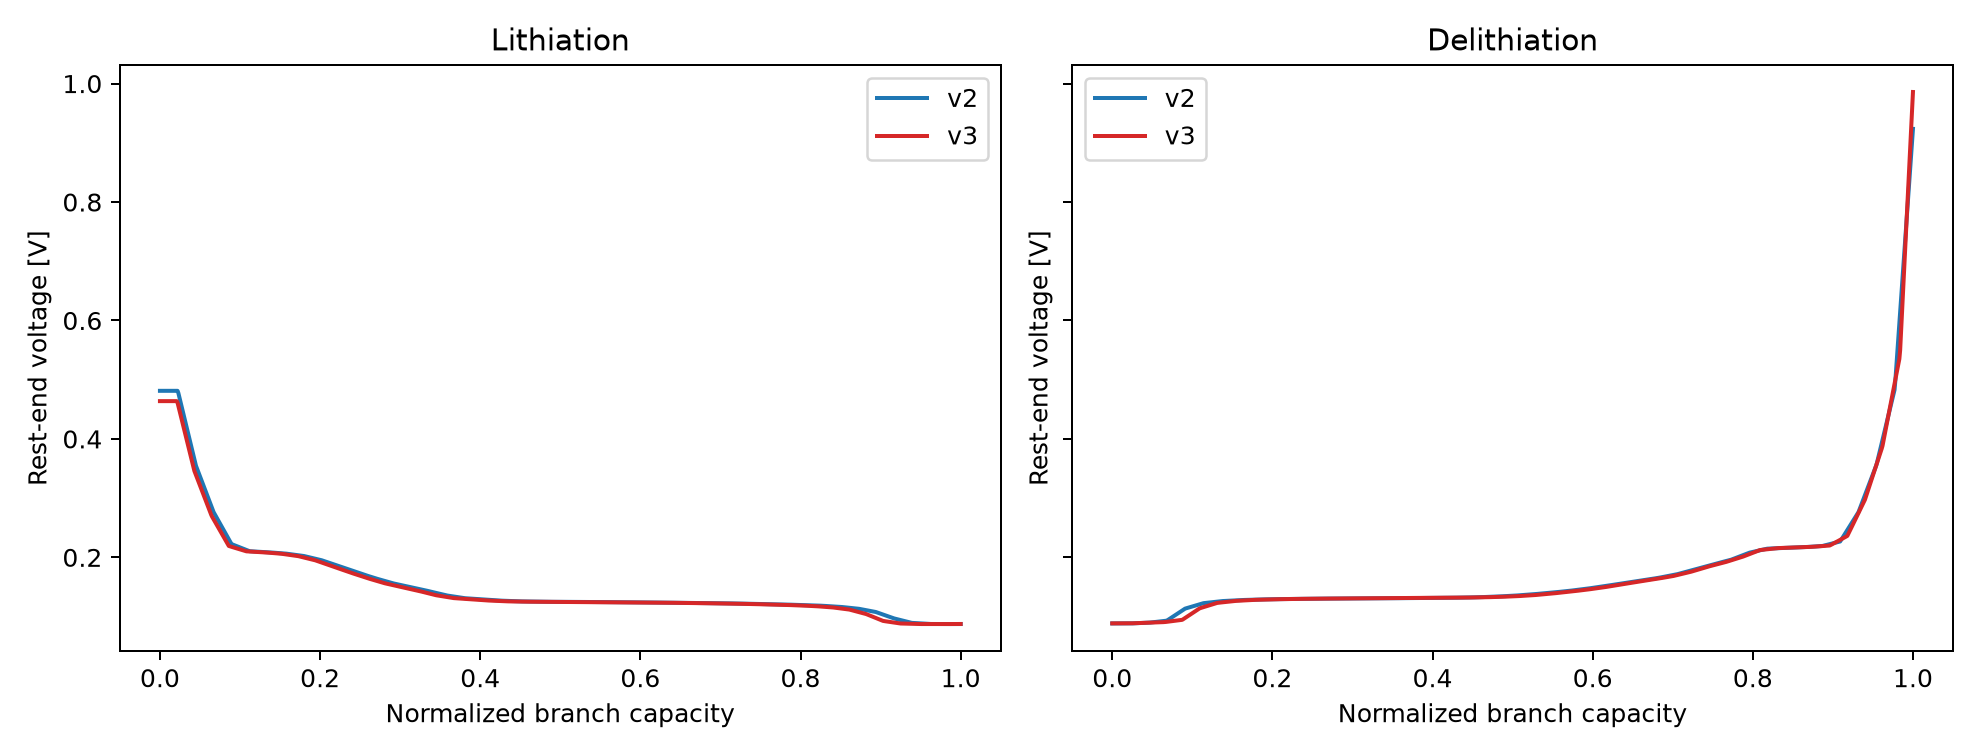

In [7]:
display(QC["reproducibility"])
display(Image(filename=str(RESULTS / "anode_v2_v3_normalized_reproducibility.png")))

## Section G — Representative new anode OCP candidate

In [8]:
Q_NORM_NEW = QC["candidate"]["Q_NORM_NEW"].to_numpy()
UN_NEW_NORM_CANDIDATE = QC["candidate"]["UN_NEW_NORM_CANDIDATE_V"].to_numpy()
display(QC["candidate"].head())
print("Axis status: normalized position only; absolute stoichiometry is not assigned.")

,Q_NORM_NEW,UN_NEW_LITH_MEAN_V,UN_NEW_DELITH_MEAN_V,UN_NEW_NORM_CANDIDATE_V,axis_interpretation
0,0.000,0.4725,0.954700,0.713600,normalized_position_not_absolute_stoichiometry
1,0.001,0.4725,0.931416,0.701958,normalized_position_not_absolute_stoichiometry
2,0.002,0.4725,0.908133,0.690316,normalized_position_not_absolute_stoichiometry
3,0.003,0.4725,0.884849,0.678674,normalized_position_not_absolute_stoichiometry
4,0.004,0.4725,0.861565,0.667033,normalized_position_not_absolute_stoichiometry


Axis status: normalized position only; absolute stoichiometry is not assigned.


## Section H — Legacy vs new normalized OCP shape

,comparison,region,axis_interpretation,MAE_mV,RMSE_mV,median_absolute_difference_mV,P90_absolute_difference_mV,max_absolute_difference_mV
0,legacy_minus_new_normalized_candidate,full_overlap,normalized_shape_only_not_absolute_stoichiometry,32.87052,39.802712,30.455781,50.272231,504.750000
1,legacy_minus_new_normalized_candidate,central_10_90,normalized_shape_only_not_absolute_stoichiometry,31.22842,33.663243,31.196950,49.662337,50.602875


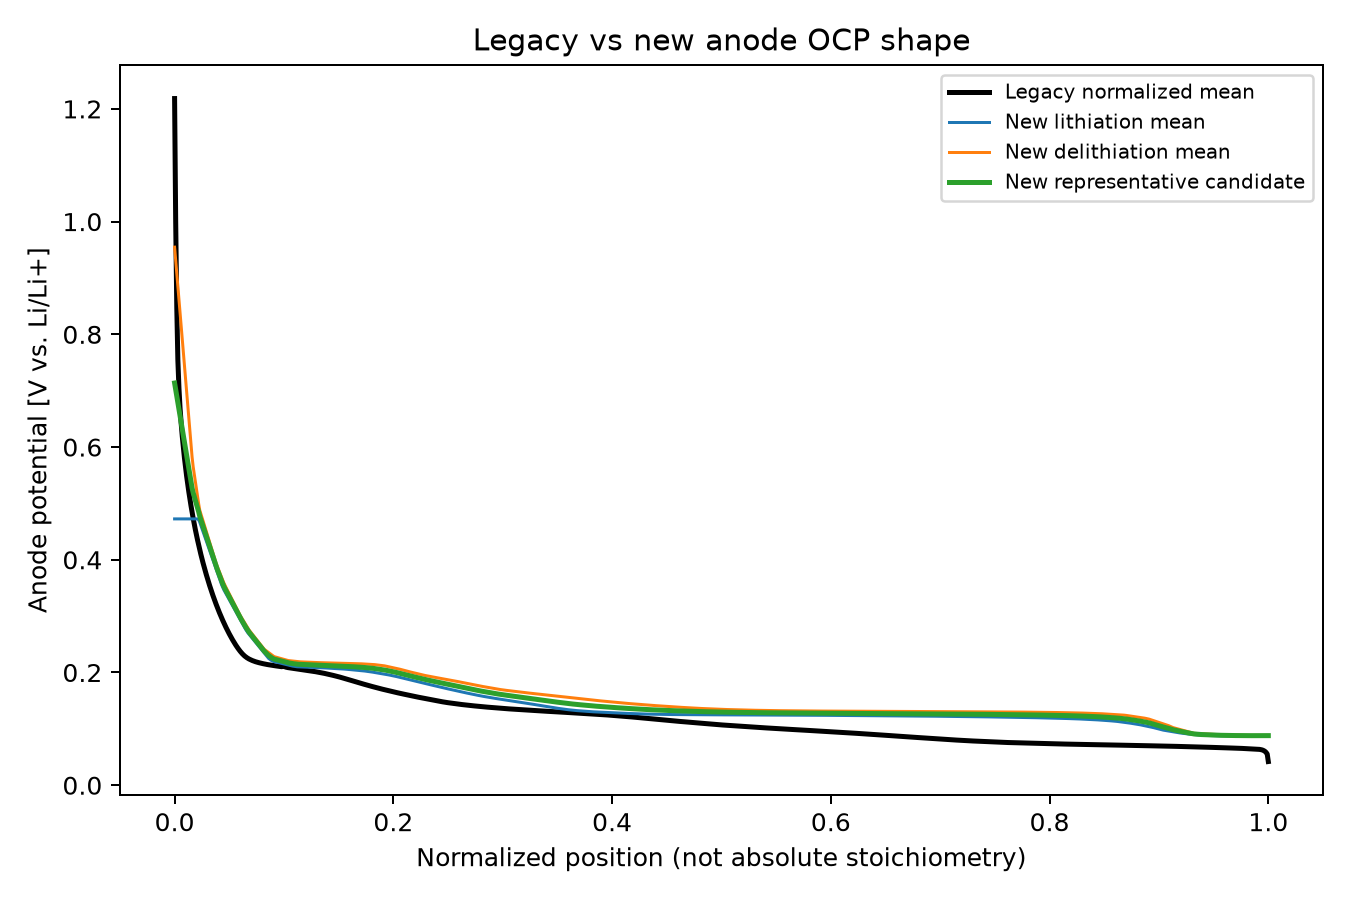

In [9]:
display(QC["legacy_metrics"])
display(Image(filename=str(RESULTS / "legacy_vs_new_anode_ocp_normalized.png")))

## Section I — OCP source switch safeguard

In [10]:
ANODE_OCP_CASE = "legacy"
display(pd.DataFrame([select_anode_ocp_source(ANODE_OCP_CASE)]))
display(pd.DataFrame([select_anode_ocp_source("new_2h_candidate")]))

,case,status
0,legacy,READY_EXISTING_METHOD


,case,status,reason
0,new_2h_candidate,NOT_READY,Q_NORM_NEW is not absolute stoichiometry; Stag...


`new_2h_candidate` remains `NOT_READY` unless an explicit absolute stoichiometry mapping is supplied.

## Section J — Stage 1 comparison skeleton

In [11]:
display(QC['stage1_skeleton'])

,case,anode_source,cathode_source,status,blocking_reason,x0,x100,y0,y100,DX,DY,endpoint_0_error_mV,endpoint_100_error_mV,qOCV_RMSE_full_mV,qOCV_MAE_full_mV,qOCV_RMSE_2_98_mV,qOCV_MAE_2_98_mV
0,A,legacy,legacy_current,READY_EXISTING_METHOD,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B,new_2h_candidate,legacy_current,NOT_READY,absolute anode stoichiometry mapping not estab...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C,legacy,new_2h_candidate,NOT_READY,final cathode 2 h GITT data unavailable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D,new_2h_candidate,new_2h_candidate,NOT_READY,absolute anode mapping and final cathode data ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Case B–D are intentionally not executed. The existing endpoint-constrained Stage 1 method is not changed.

## Cathode 2 h GITT placeholder

In [12]:
display(QC['cathode_placeholder'])

,component,status,planned_pipeline,final_ocp_used
0,cathode_2h_gitt,WAITING_FOR_FINAL_RAW_DATA,pulse/rest parser; 1h-vs-2h; last-10-min dV/dt...,False


## Saved outputs

In [13]:
for path in sorted(RESULTS.iterdir()):
    print(path.name)

anode_1h_vs_2h_relaxation.csv
anode_1h_vs_2h_relaxation_metrics.csv
anode_capacity_qc.csv
anode_normalized_ocp_candidate.csv
anode_pulse_rest_summary.csv
anode_rest_1h_vs_2h.png
anode_rest_equilibrium.csv
anode_rest_equilibrium.png
anode_rest_equilibrium_metrics.csv
anode_v2_v3_normalized_reproducibility.png
anode_v2_v3_reproducibility.csv
cathode_2h_placeholder.csv
legacy_vs_new_anode_ocp_metrics.csv
legacy_vs_new_anode_ocp_normalized.png
parser_status.csv
qc_manifest.json
stage1_comparison_skeleton.csv
